In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## DATA LOADING

In [2]:
# Import dataset
df=pd.read_csv(r"C:\Users\HP\Downloads\exam_score_prediction\Exam_Score_Prediction.csv")
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [3]:
from sklearn.preprocessing import LabelEncoder

# List of columns to encode
columns = [
    "gender",
    "course",
    "internet_access",
    "sleep_quality",
    "study_method",
    "facility_rating",
    "exam_difficulty"
]

# Store encoders and dictionaries
encoders = {}
mappings = {}

for col in columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    
    # Save encoder
    encoders[col] = le
    
    # Create mapping dictionary
    mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# 🔍 Print all mappings
for col, mapping in mappings.items():
    print(f"{col}:", mapping)



gender: {'female': np.int64(0), 'male': np.int64(1), 'other': np.int64(2)}
course: {'b.com': np.int64(0), 'b.sc': np.int64(1), 'b.tech': np.int64(2), 'ba': np.int64(3), 'bba': np.int64(4), 'bca': np.int64(5), 'diploma': np.int64(6)}
internet_access: {'no': np.int64(0), 'yes': np.int64(1)}
sleep_quality: {'average': np.int64(0), 'good': np.int64(1), 'poor': np.int64(2)}
study_method: {'coaching': np.int64(0), 'group study': np.int64(1), 'mixed': np.int64(2), 'online videos': np.int64(3), 'self-study': np.int64(4)}
facility_rating: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}
exam_difficulty: {'easy': np.int64(0), 'hard': np.int64(1), 'moderate': np.int64(2)}


In [5]:
print(type(encoders["gender"]))

<class 'sklearn.preprocessing._label.LabelEncoder'>


In [7]:
import pickle

# Save mappings dictionary
#with open("encoder_mappings.pkl", "wb") as f:
  # pickle.dump(mappings, f)

#Save encoders also (optional but useful)
with open("encoderssss.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [9]:
for col, encoder in encoders.items():
    print(f"{col}: {encoder.classes_}")

gender: ['female' 'male' 'other']
course: ['b.com' 'b.sc' 'b.tech' 'ba' 'bba' 'bca' 'diploma']
internet_access: ['no' 'yes']
sleep_quality: ['average' 'good' 'poor']
study_method: ['coaching' 'group study' 'mixed' 'online videos' 'self-study']
facility_rating: ['high' 'low' 'medium']
exam_difficulty: ['easy' 'hard' 'moderate']


In [8]:
encoders["study_method"].classes_

array(['coaching', 'group study', 'mixed', 'online videos', 'self-study'],
      dtype=object)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


## DATA CLEANING AND PREPROCESSING

In [9]:
# Convert categorical columns to numerical using label encoder
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
course_encoder = LabelEncoder()
internet_encoder = LabelEncoder()
sleep_encoder = LabelEncoder()
study_encoder = LabelEncoder()
facility_encoder = LabelEncoder()
exam_encoder = LabelEncoder()

df["gender"] = gender_encoder.fit_transform(df["gender"])
df["course"] = course_encoder.fit_transform(df["course"])
df["internet_access"] = internet_encoder.fit_transform(df["internet_access"])
df["sleep_quality"] = sleep_encoder.fit_transform(df["sleep_quality"])
df["study_method"] = study_encoder.fit_transform(df["study_method"])
df["facility_rating"] = facility_encoder.fit_transform(df["facility_rating"])
df["exam_difficulty"] = exam_encoder.fit_transform(df["exam_difficulty"])

In [10]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9
1,2,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8
2,3,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3
3,4,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7
4,5,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7


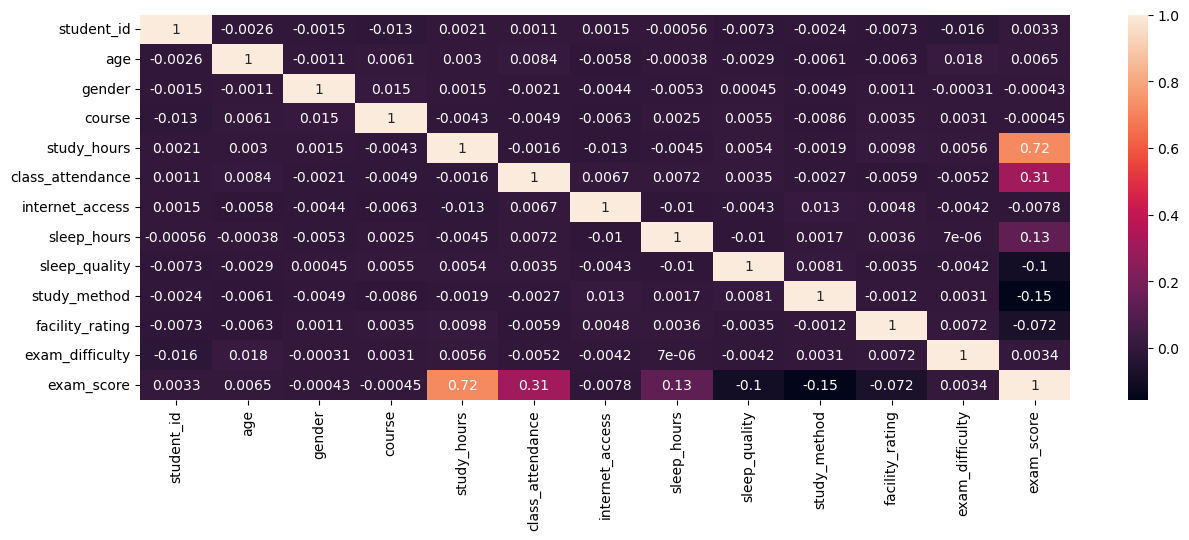

In [11]:
# To find correlation between the variables
corr = df.corr()
plt.figure(figsize=(15,5))
sns.heatmap(corr,annot=True)
plt.show()

In [12]:
# Drop non correlated columns
df.drop('exam_difficulty',axis=1,inplace=True)
df.drop('student_id',axis=1,inplace=True)
df.drop('age',axis=1,inplace=True)
df.drop('course',axis=1,inplace=True)

In [13]:
df.head()

,gender,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_score
0,1,2.78,92.9,1,7.4,2,0,1,58.9
1,2,3.37,64.8,1,4.6,0,3,2,54.8
2,1,7.88,76.8,1,8.5,2,0,0,90.3
3,2,0.67,48.4,1,5.8,0,3,1,29.7
4,0,0.89,71.6,1,9.8,2,0,1,43.7


## EXPLORATORY DATA ANALYSIS

### SCATTER PLOT

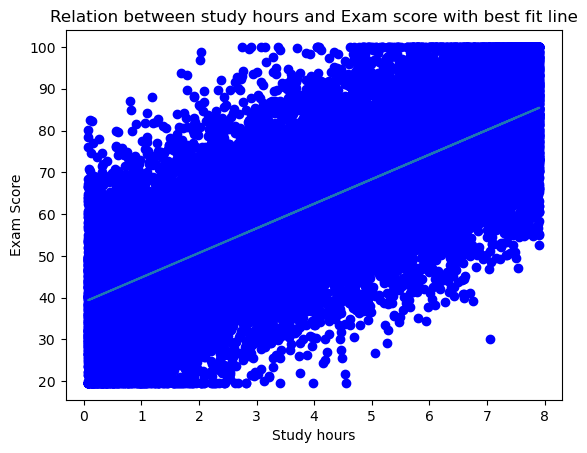

In [14]:
# Scatter plot for analysing the relation between study hours and Exam score
x=df['study_hours']
y= df['exam_score']
plt.scatter(x, y, color='blue', marker = 'o')
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)
plt.xlabel('Study hours')
plt.ylabel('Exam Score')
plt.title('Relation between study hours and Exam score with best fit line')
plt.show()

### HISTOGRAM

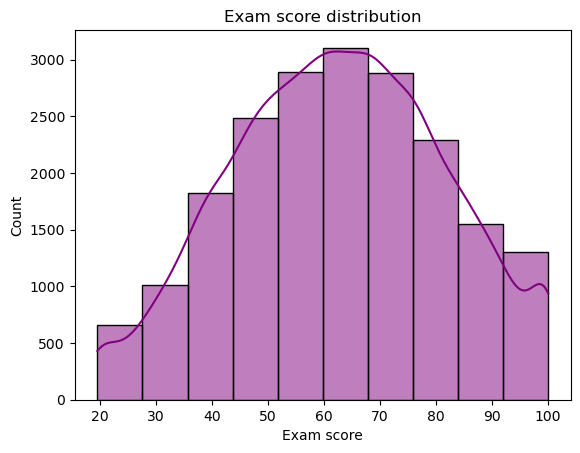

In [15]:
# Exam score distribution

sns.histplot(df['exam_score'],bins = 10, kde = True, color = 'purple')
plt.xlabel('Exam score')
plt.ylabel('Count')
plt.title('Exam score distribution')
plt.show()

### PIE PLOT

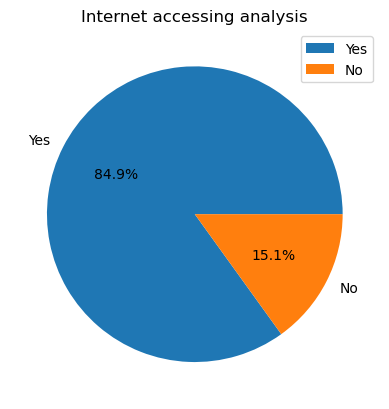

In [16]:
# Relation between Internet accessing analysis 
labels= ['Yes','No']
count = df['internet_access'].value_counts()
plt.pie(count,labels=labels,autopct='%1.1f%%')
plt.legend()
plt.title('Internet accessing analysis')
plt.show()

## TRAIN TEST SPLIT


In [17]:
# Split the whole dataset to X and y to train the model
X = df.drop('exam_score',axis=1)
X.head()

,gender,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating
0,1,2.78,92.9,1,7.4,2,0,1
1,2,3.37,64.8,1,4.6,0,3,2
2,1,7.88,76.8,1,8.5,2,0,0
3,2,0.67,48.4,1,5.8,0,3,1
4,0,0.89,71.6,1,9.8,2,0,1


In [18]:
y = df['exam_score']
y.head()

0    58.9
1    54.8
2    90.3
3    29.7
4    43.7
Name: exam_score, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=24)

In [20]:
from sklearn.preprocessing import StandardScaler
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.decomposition import PCA
# Apply PCA
pca = PCA(n_components=2)  # reduce to 2 principal components
X_pca = pca.fit_transform(X_scaled)

In [22]:
# Convert PCA result to DataFrame
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
print("PCA Transformed Data (first 5 rows):")
print(X_pca_df.head())

PCA Transformed Data (first 5 rows):
        PC1       PC2
0  0.209138  0.230330
1  0.132118 -0.654929
2 -0.906926 -0.156686
3  0.700076 -0.073001
4  0.622394  1.285595


In [23]:
# 6️⃣ Explained variance ratio
explained_var = pca.explained_variance_ratio_
print("\nExplained Variance Ratio:")
for i, var in enumerate(explained_var):
    print(f"PC{i+1}: {var:.2f}")


Explained Variance Ratio:
PC1: 0.13
PC2: 0.13


In [24]:
# 7️⃣ Feature importance (average absolute loading)
feature_importance = np.abs(pca.components_).mean(axis=0)
feature_rank = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print("\nFeature ranking by PCA importance:")
print(feature_rank)


Feature ranking by PCA importance:
            Feature  Importance
1       study_hours    0.388447
3   internet_access    0.384545
6      study_method    0.363603
4       sleep_hours    0.341054
5     sleep_quality    0.290165
2  class_attendance    0.222815
0            gender    0.216556
7   facility_rating    0.097562


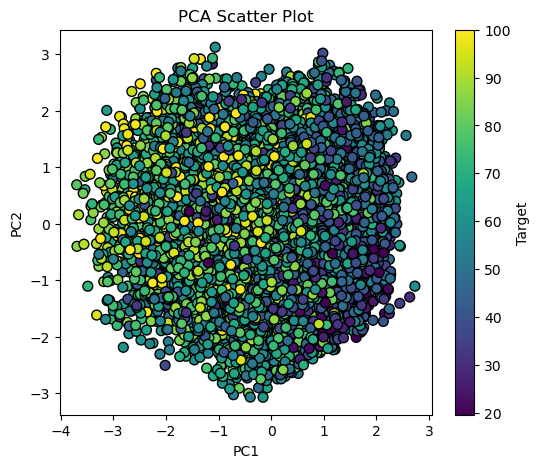

In [25]:
# 8️⃣ Optional: Plot PCA scatter
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Scatter Plot')
plt.colorbar(label='Target')
plt.savefig('PCA')
plt.show()

## MODELLING

### LINEAR REGRESSION

In [26]:
from sklearn.linear_model import LinearRegression
model_LR = LinearRegression()
model_LR.fit(X_train,y_train)

LinearRegression()

In [27]:
y_pred =model_LR.predict(X_test)

In [28]:
# To check the accuracy of Linear Regression Model
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² score:", r2)


R² score: 0.6735781037072114


In [29]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Display Results
print("R-squared (R2)      :", r2)
print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root MSE            :", rmse)

R-squared (R2)      : 0.6735781037072114
Mean Absolute Error : 8.852160743478624
Mean Squared Error  : 118.66730561240033
Root MSE            : 10.89345241933889


### Random Forest Regressor

In [30]:
from sklearn.ensemble import RandomForestRegressor
model_RFR = RandomForestRegressor()
model_RFR.fit(X_train,y_train)

RandomForestRegressor()

In [31]:
y_pred = model_RFR.predict(X_test)

In [32]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² score:", r2)

R² score: 0.6952598592475147


### SVR

In [33]:
from sklearn.svm import SVR
model_SVR = SVR()
model_SVR.fit(X_train,y_train)

SVR()

In [34]:
y_pred = model_SVR.predict(X_test)

In [35]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² score:", r2)

R² score: 0.6008981918395595


### KNeighbors Regressor

In [36]:
from sklearn.neighbors import KNeighborsRegressor
model_KNR = KNeighborsRegressor()
model_KNR.fit(X_train,y_train)

KNeighborsRegressor()

In [37]:
y_pred = model_KNR.predict(X_test)

In [38]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² score:", r2)

R² score: 0.6275113034179658


### MLP Regressor

In [39]:
from sklearn.neural_network import MLPRegressor
model_MLPR = MLPRegressor()
model_MLPR.fit(X_train,y_train)

MLPRegressor()

In [40]:
y_pred = model_MLPR.predict(X_test)

In [41]:
r2 = r2_score(y_test, y_pred)
print("R² score:", r2)

R² score: 0.7177607112092554


<p> The objective of this project was to predict/classify Exam Score using Exam_Score_Prediction dataset and identify the most suitable machine learning model.Multiple models including Linear Regression,  Random Forest, MLP Regressor, KNeighbors Regressor and Support Vector Machine were trained and evaluated.Models were evaluated using r2 score on the test dataset. The MLP Regressor model showed the highest R² value (0.72), indicating better predictive performance. Hence, it is selected as the best-fit model for this project and is recommended for deployment.</p>

In [44]:
import joblib

# Save Label Encoder
import joblib

encoders = {
    "gender": gender_encoder,
    "internet_access": internet_encoder,
    "sleep_quality": sleep_encoder,
    "study_method": study_encoder,
    "facility_rating": facility_encoder
}

joblib.dump(encoders, "encoders.pkl")

# Save Scaler
joblib.dump(scaler, "scaler.pkl")

# Save Model
joblib.dump(model_MLPR, "model.pkl")

print("✅ Model, Scaler, and Encoder saved!")

✅ Model, Scaler, and Encoder saved!
